# Python Data Analysis Minimum

This notebook shows the smallest data analysis workflow you need before entering the regression and forecasting modules: load data, inspect it, plot it, fit a simple model, predict, and write a result.


## 1. Load packages

In JupyterLite, run the setup cell below. In a local Jupyter environment, you can install the same packages once with `%pip install numpy pandas matplotlib scipy statsmodels`, then run the imports.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()


Using the current Python environment.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


## 2. Read the data

The sample data are weekly observations for a small online store. The response is `sales`. The predictors are `visitors` and a promotion indicator `promo`, where 1 means a promotion was active and 0 means it was not.


In [3]:
data = pd.read_csv("data/student_onboarding_sales.csv")
data.head()


,week,visitors,promo,sales
0,1,118,0,22.1
1,2,126,0,23.4
2,3,131,1,27.7
3,4,129,0,24.1
4,5,143,1,30.2


## 3. Inspect the data before modeling

Before fitting a model, check the shape, column names, variable types, missing values, and simple summaries. This habit prevents many avoidable mistakes.


In [4]:
print("Rows and columns:", data.shape)
print("\nColumn types:")
print(data.dtypes)
print("\nMissing values:")
print(data.isna().sum())


Rows and columns: (12, 4)

Column types:
week          int64
visitors      int64
promo         int64
sales       float64
dtype: object

Missing values:
week        0
visitors    0
promo       0
sales       0
dtype: int64


In [5]:
data.describe()


,week,visitors,promo,sales
count,12.000000,12.000000,12.000000,12.000000
mean,6.500000,152.333333,0.500000,30.900000
std,3.605551,23.917788,0.522233,6.003484
min,1.000000,118.000000,0.000000,22.100000
25%,3.750000,130.500000,0.000000,26.800000
50%,6.500000,150.500000,0.500000,31.150000
75%,9.250000,171.500000,1.000000,35.125000
max,12.000000,191.000000,1.000000,41.000000


## 4. Plot the main relationship

A plot is not decoration. It is how you check whether the model you are about to fit is plausible enough to be useful.


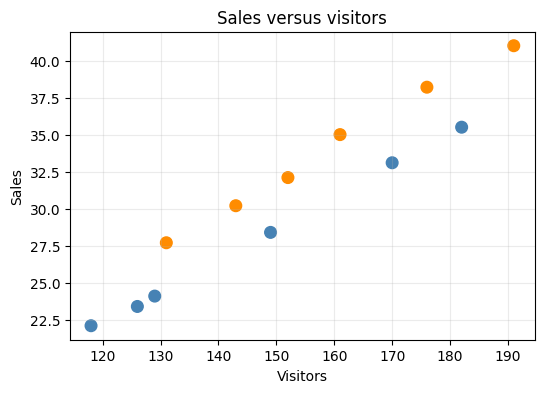

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = data["promo"].map({0: "steelblue", 1: "darkorange"})
ax.scatter(data["visitors"], data["sales"], c=colors, s=70)
ax.set_xlabel("Visitors")
ax.set_ylabel("Sales")
ax.set_title("Sales versus visitors")
ax.grid(True, alpha=0.25)
plt.show()


## 5. Fit a simple regression model

The model below estimates average sales as a linear function of visitors and promotion status:

$$
\text{sales}_i = \beta_0 + \beta_1 \text{visitors}_i + \beta_2 \text{promo}_i + \epsilon_i.
$$

The formula syntax `sales ~ visitors + promo` means: model `sales` using `visitors` and `promo` as predictors.


In [7]:
model = smf.ols("sales ~ visitors + promo", data=data).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     1775.
Date:                Mon, 18 May 2026   Prob (F-statistic):           2.06e-12
Time:                        17:02:45   Log-Likelihood:                -2.1336
No. Observations:                  12   AIC:                             10.27
Df Residuals:                       9   BIC:                             11.72
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.2163      0.655     -6.437      0.000      -5.698      -2.735
visitors       0.2196      0.004     49.922      0.000       0.210       0.230
promo          3.3392      0.201     16.577      0.000       2.884       3.795
==============================================================================
Omnibus:                        1.456   Durbin-Watson:                   1.818
Prob(Omnibus):                  0.483   Jarque-Bera (JB):                1.119
Skew:                           0.618   Prob(JB):                        0.571
Kurtosis:                       2.157   Cond. No.                     1.05e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 6. Extract and interpret key results

Use model output as evidence, then write the conclusion in the language of the problem. Do not submit only a table.


In [8]:
print("Estimated coefficients:")
print(model.params)
print("\nR-squared:", round(model.rsquared, 3))


Estimated coefficients:
Intercept   -4.216263
visitors     0.219562
promo        3.339167
dtype: float64

R-squared: 0.997


A compact interpretation could look like this:

In this fitted model, one additional visitor is associated with an estimated increase of about `visitors` coefficient sales units on average, holding promotion status fixed. Weeks with a promotion are estimated to have about `promo` coefficient more sales units on average than comparable weeks without a promotion, holding visitors fixed.

In real homework answers, replace the placeholders with the actual values from your code output.


## 7. Predict for a new case

Prediction means applying the fitted model to new predictor values. Always make sure the new data frame uses the same variable names used in the model formula.


In [9]:
new_weeks = pd.DataFrame({
    "visitors": [150, 180],
    "promo": [0, 1]
})

predicted_sales = model.predict(new_weeks)
new_weeks.assign(predicted_sales=predicted_sales)


,visitors,promo,predicted_sales
0,150,0,28.718104
1,180,1,38.644145


## 8. A reusable mini-template

Most course notebooks use this same rhythm: read data, inspect, visualize, model, diagnose, interpret, and predict or forecast.


In [10]:
def quick_regression(data, formula):
    fitted = smf.ols(formula, data=data).fit()
    print(fitted.summary())
    return fitted

simple_model = quick_regression(data, "sales ~ visitors")


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     115.4
Date:                Mon, 18 May 2026   Prob (F-statistic):           8.22e-07
Time:                        17:02:45   Log-Likelihood:                -22.840
No. Observations:                  12   AIC:                             49.68
Df Residuals:                      10   BIC:                             50.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.7801      3.453     -1.674      0.1

## Practice

Modify the code below to compare the two models:

- `sales ~ visitors`
- `sales ~ visitors + promo`

Report which model has the larger $R^2$, then write one sentence explaining why a larger $R^2$ alone is not the only thing we care about.


In [11]:
# ANSWER: write your comparison code here.

model_a = smf.ols("sales ~ visitors", data=data).fit()
model_b = smf.ols("sales ~ visitors + promo", data=data).fit()

print("Model A R-squared:", round(model_a.rsquared, 3))
print("Model B R-squared:", round(model_b.rsquared, 3))


Model A R-squared: 0.92
Model B R-squared: 0.997


**ANSWER:**

Write your interpretation here.
